In [25]:
import numpy as np
import pandas as pd
import seaborn as sns

In [26]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [27]:
df.shape

(10000, 3)

In [28]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

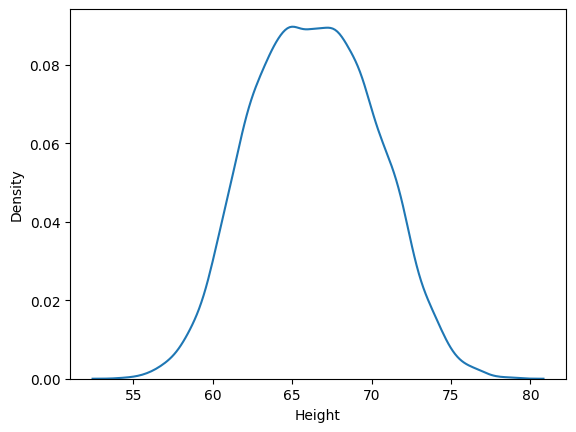

In [29]:
sns.kdeplot(df['Height'])


<Axes: ylabel='Height'>

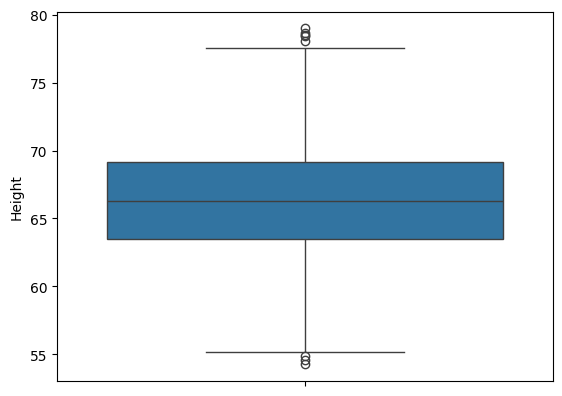

In [30]:
sns.boxplot(df['Height'])

In [31]:
# add our own quantail
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [32]:
#bcz upper is 99 so lower is 1
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [33]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [34]:
new_df['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

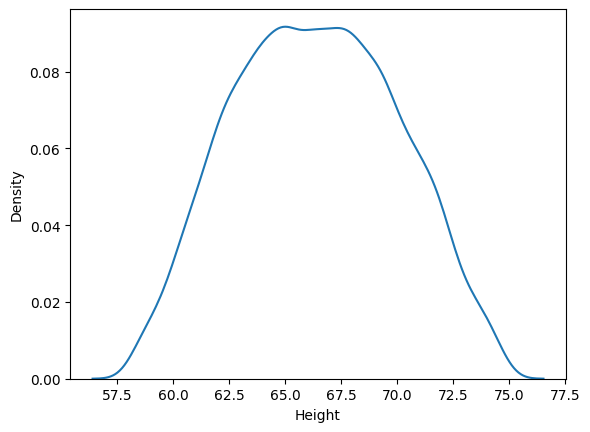

In [35]:
sns.kdeplot(new_df['Height'])

<Axes: ylabel='Height'>

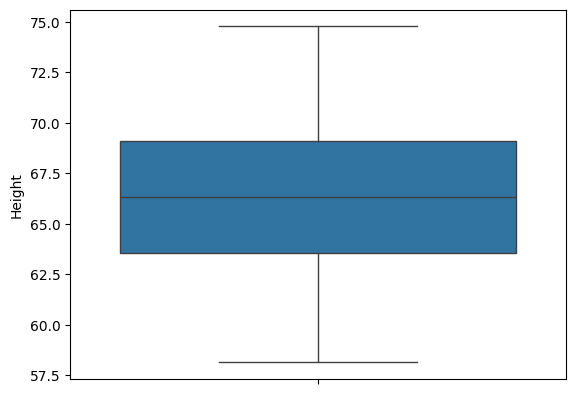

In [36]:
sns.boxplot(new_df['Height'])

In [39]:
# Capping --> Winsorization
new_cap_df=df.copy()
new_cap_df['Height']=np.where(df['Height']>=upper_limit,upper_limit,
                    np.where(df['Height']<=lower_limit,lower_limit,
                             df['Height']))
new_cap_df.shape

(10000, 3)

<Axes: xlabel='Height', ylabel='Density'>

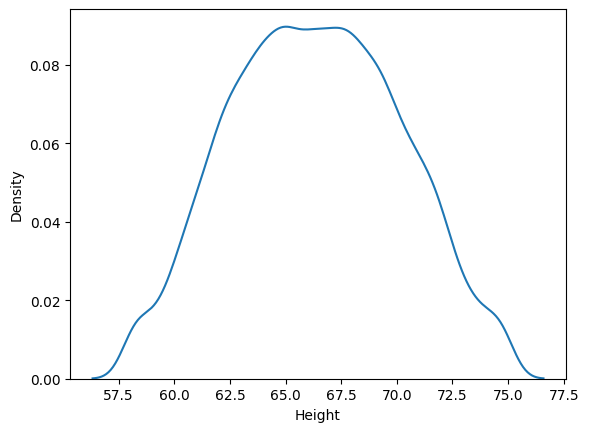

In [40]:
sns.kdeplot(new_cap_df['Height'])

<Axes: ylabel='Height'>

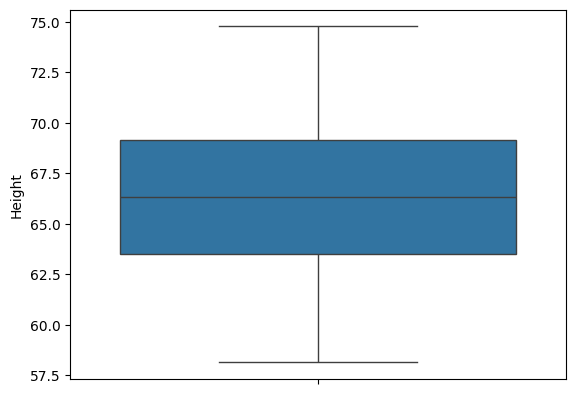

In [41]:
sns.boxplot(new_cap_df['Height'])